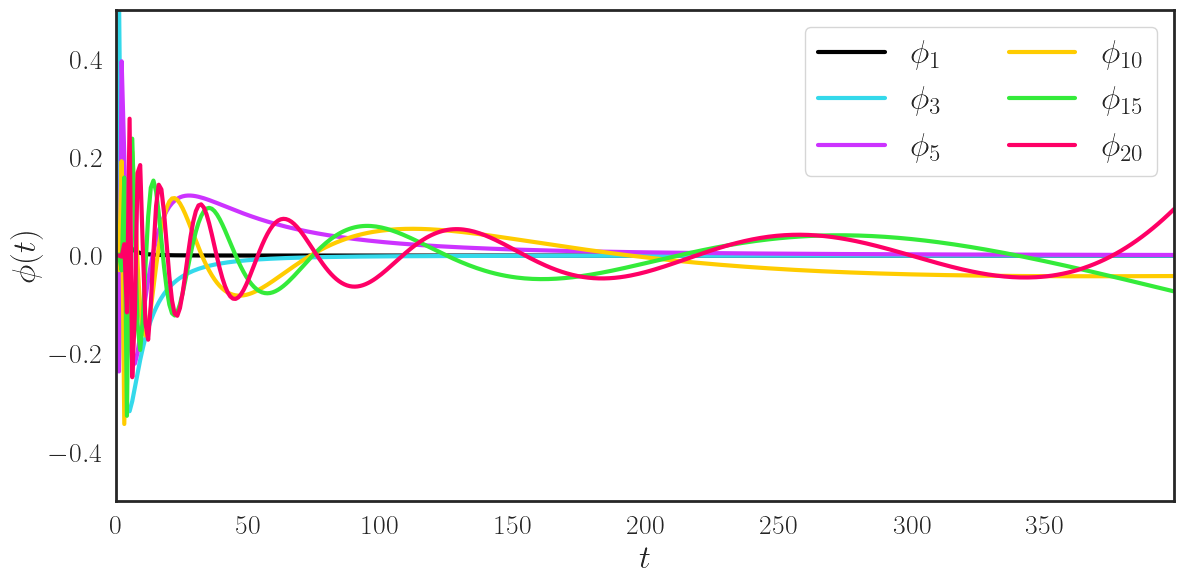

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# LaTeX + serif style
# ------------------------------
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
sns.set(style="white")

# ------------------------------
# Construct Hankel matrix and compute eigenvectors
# ------------------------------
def construct_hankel_matrix(T):
    Z = np.zeros((T, T))
    for i in range(1, T+1):
        for j in range(1, T+1):
            Z[i-1, j-1] = 2 / (((i + j)**3) - (i + j))

    eigvals, eigvecs = np.linalg.eigh(Z)
    # Sort eigenvectors by descending eigenvalues
    pairs = sorted(zip(eigvals, eigvecs.T), key=lambda x: -x[0])
    eigvals = np.array([p[0] for p in pairs])
    eigvecs = np.column_stack([p[1] for p in pairs])
    return eigvals, eigvecs

T = 400
eigvals, eigvecs = construct_hankel_matrix(T)

# ------------------------------
# Plot selected eigenvectors
# ------------------------------
selected_indices = [0, 2, 4, 9, 14, 19]  # Python indexing: 1,3,5,10,15,20
colors = ["#000000", "#34d9eb", "#cc33ff", "#ffcc00", "#34eb3a", "#ff0066"]

fig, ax = plt.subplots(figsize=(12, 6))

for i, idx in enumerate(selected_indices):
    ax.plot(range(T), eigvecs[:, idx], lw=3, color=colors[i], markevery=3, label=fr"$\phi_{{{idx+1}}}$")

# Titles and labels
ax.set_xlabel(r"$t$", fontsize=24, fontweight='bold')
ax.set_ylabel(r"$\phi(t)$", fontsize=24, fontweight='bold')
ax.set_ylim(-0.5, 0.5)
ax.margins(y=0)
ax.margins(x=0)

# Boxed style: all spines visible and bold
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

ax.tick_params(width=2, labelsize=20)
ax.legend(fontsize=24, ncol=2)
ax.grid(False)

plt.tight_layout()
fig.savefig("filters-fig.png", dpi=300)
plt.show()